# 03 — Feature Engineering

This notebook covers **feature selection** (removing redundant/uninformative features) and **dimensionality reduction (PCA)**, and justifies the final feature set carried into modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

sns.set_style('whitegrid')
df = pd.read_csv('../data/processed/life_expectancy_clean.csv')
y = df['life_expectancy']
country_series = df['country']  # kept aside as an ID column, not a model feature
X = df.drop(columns=['life_expectancy', 'country'])
print(X.shape)

(2928, 20)


**Note on `country`:** it's excluded from the model's feature set here (193 categories is too high-cardinality to one-hot encode sensibly, and target-encoding it risks leaking country-level average life expectancy straight into the model). We keep it aside only as an ID column so we can trace individual predictions back to a country during error analysis in notebook 05 — it never enters training.

## Step 1 — Remove redundant features
From the notebook 01/02 correlation analysis, two feature pairs are near-duplicates (correlation > 0.85):
- `infant_deaths` and `under_five_deaths` (r = 0.996) — under-five deaths structurally include infant deaths, so they measure almost the same thing.
- `thinness_10_19_years` and `thinness_5_9_years` (r = 0.939) — same underlying malnutrition signal at two adjacent age bands.

Keeping both members of a pair adds noise/multicollinearity without adding information, so we drop one from each pair (`infant_deaths`, `thinness_5_9_years`) and keep the more complete/standard measure.

In [2]:
X = X.drop(columns=['infant_deaths', 'thinness_5_9_years'])
print('Shape after removing redundant features:', X.shape)

Shape after removing redundant features: (2928, 18)


## Step 2 — Feature selection
We combine three independent signals rather than trusting any single method:
1. **Correlation with target** — linear relationships.
2. **Mutual information** — captures non-linear relationships correlation would miss.
3. **Random Forest feature importance** — captures interactions between features.

A feature that ranks low on *all three* is a strong candidate to drop.

In [3]:
corr_scores = X.corrwith(y).abs().sort_values(ascending=False)

mi_scores = pd.Series(
    mutual_info_regression(X, y, random_state=42),
    index=X.columns
).sort_values(ascending=False)

rf_probe = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_probe.fit(X, y)
rf_scores = pd.Series(rf_probe.feature_importances_, index=X.columns).sort_values(ascending=False)

ranking = pd.DataFrame({
    'corr_rank': corr_scores.rank(ascending=False),
    'mutual_info_rank': mi_scores.rank(ascending=False),
    'rf_importance_rank': rf_scores.rank(ascending=False),
})
ranking['avg_rank'] = ranking.mean(axis=1)
ranking = ranking.sort_values('avg_rank')
ranking

,corr_rank,mutual_info_rank,rf_importance_rank,avg_rank
income_composition,2.0,2.0,2.0,2.000000
adult_mortality,3.0,1.0,3.0,2.333333
schooling,1.0,4.0,5.0,3.333333
under_five_deaths,4.0,6.0,4.0,4.666667
hiv_aids,7.0,7.0,1.0,5.000000
bmi,6.0,5.0,6.0,5.666667
thinness_10_19_years,10.0,3.0,7.0,6.666667
gdp,5.0,8.0,14.0,9.000000
alcohol,12.0,9.0,8.0,9.666667
polio,11.0,12.0,11.0,11.333333


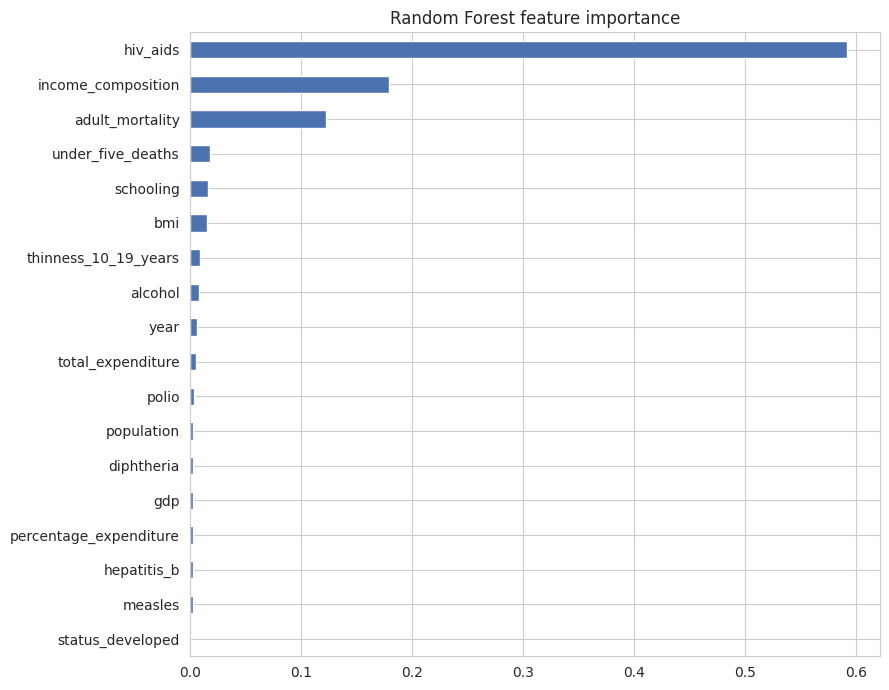

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
rf_scores.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Random Forest feature importance')
plt.tight_layout()
plt.savefig('../figures/08_feature_importance.png', dpi=120)
plt.show()

**Observation:** `hiv_aids`, `income_composition`, `adult_mortality`, and `schooling` are consistently top-ranked across all three methods. `population` and `year` rank lowest across all three — `population` because raw population size doesn't causally drive life expectancy, and `year` because its effect is likely already captured indirectly through the other time-varying indicators (GDP, schooling, immunization all trend with year).

We drop features that rank in the **bottom quartile on every single method** (not just on average, to avoid one method's noise dropping something the others value).

In [5]:
bottom_quartile = len(X.columns) * 0.75
drop_candidates = ranking[
    (ranking['corr_rank'] > bottom_quartile) &
    (ranking['mutual_info_rank'] > bottom_quartile) &
    (ranking['rf_importance_rank'] > bottom_quartile)
].index.tolist()
print('Dropping (weak on every method):', drop_candidates)
X_selected = X.drop(columns=drop_candidates)
print('Final feature set:', X_selected.columns.tolist())
print('Shape:', X_selected.shape)

Dropping (weak on every method): ['measles']
Final feature set: ['year', 'adult_mortality', 'alcohol', 'percentage_expenditure', 'hepatitis_b', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_10_19_years', 'income_composition', 'schooling', 'status_developed']
Shape: (2928, 17)


## Step 3 — Dimensionality reduction (PCA)
We run PCA on the standardized feature set to see how much redundancy remains and whether compressing to fewer components is worthwhile.

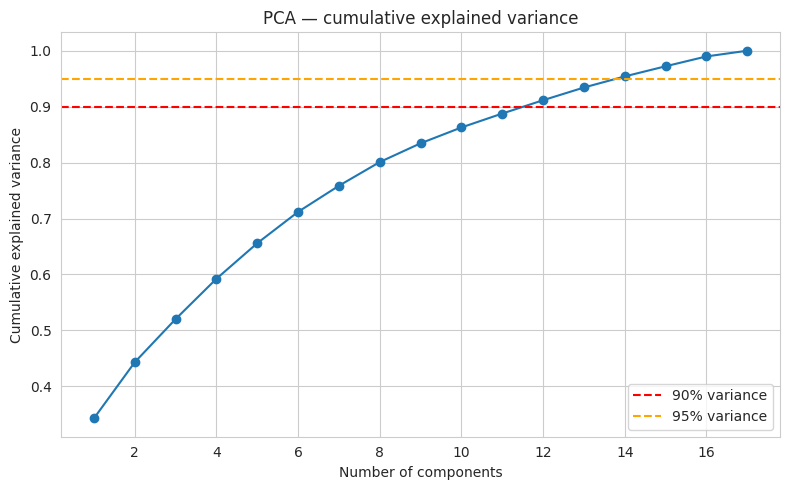

12 components needed for 90% variance (out of 17 original features)
14 components needed for 95% variance


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

pca = PCA()
pca.fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o')
ax.axhline(0.90, color='red', linestyle='--', label='90% variance')
ax.axhline(0.95, color='orange', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — cumulative explained variance')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/09_pca_variance.png', dpi=120)
plt.show()

n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f'{n_90} components needed for 90% variance (out of {X_selected.shape[1]} original features)')
print(f'{n_95} components needed for 95% variance')

## Decision: final feature set for modeling
**We do NOT use PCA components in the final model — we use the selected original features directly.** Justification:
1. PCA only compresses ~ features down to a modest number of components at 90% variance — the original feature set is already small enough (after selection) that PCA's main benefit (compression) buys little.
2. PCA components are linear combinations of standardized features and are **not interpretable** — since one of our three research questions is *which factors* predict life expectancy, we need to keep feature identity intact for the coefficient/importance analysis in notebook 05.
3. Tree-based models (one of our two model families) don't benefit from PCA the way linear models do; PCA is more useful for very high-dimensional or highly collinear feature spaces, which — after our redundant-pair removal above — this no longer is.

PCA is retained in this notebook as a documented exploration satisfying the dimensionality-reduction requirement, but the **modeling notebook uses `X_selected`** (the feature-selected, non-PCA set).

In [7]:
final_features = X_selected.columns.tolist()
print('FINAL FEATURE SET (', len(final_features), 'features ):')
for f in final_features:
    print(' -', f)

# Save the final modeling-ready dataset (country kept only as a non-feature ID column)
final_df = X_selected.copy()
final_df['life_expectancy'] = y.values
final_df['country'] = country_series.values
final_df.to_csv('../data/processed/life_expectancy_features.csv', index=False)
print('\nSaved to data/processed/life_expectancy_features.csv, shape:', final_df.shape)

FINAL FEATURE SET ( 17 features ):
 - year
 - adult_mortality
 - alcohol
 - percentage_expenditure
 - hepatitis_b
 - bmi
 - under_five_deaths
 - polio
 - total_expenditure
 - diphtheria
 - hiv_aids
 - gdp
 - population
 - thinness_10_19_years
 - income_composition
 - schooling
 - status_developed

Saved to data/processed/life_expectancy_features.csv, shape: (2928, 19)
